In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import ast
from collections import defaultdict

In [2]:
galaxy_dataframe = pd.read_csv('Galaxy_dataframe_TNG.csv')

galaxy_dataframe.head() 


,gal_number,r_half,r_half_index,z_half,z_half_index,ratio,stellar_mass,T_total_mass,gas_r_half,gas_r_half_index,gas_z_half,gas_z_half_index,gas_ratio,gas_total_mass,specific_angular_mom,h1_specific_angular_mom,gas_COM,max_R
0,220595,18.568521,6825896.0,4.545219,6785286.0,0.244781,5.458463e+11,2.095424e+12,24.598475,272789.0,6.047934,272673.0,0.245866,2.104261e+10,"[np.float64(1.1328268664093131e-14), np.float6...","[np.float64(7.859191262280695e-14), np.float64...","[np.float64(9651.136240542759), np.float64(883...",684.128790
1,220596,3.100749,2479256.0,0.894084,2464623.0,0.288345,1.922522e+11,1.973363e+11,13.610447,13795.0,3.678655,13937.0,0.270282,1.399189e+09,"[np.float64(1.576731449739062e-14), np.float64...","[np.float64(2.8929019062066474e-14), np.float6...","[np.float64(9534.667645609297), np.float64(893...",85.664986
2,220597,5.029999,568135.0,0.791481,556108.0,0.157352,4.444406e+10,6.068907e+10,9.942229,56191.0,1.190902,57535.0,0.119782,3.872078e+09,"[np.float64(1.0184258360902912e-14), np.float6...","[np.float64(1.8268029492337607e-14), np.float6...","[np.float64(9508.726316688222), np.float64(890...",75.093297
3,220598,6.209337,161395.0,0.553286,158205.0,0.089105,1.303080e+10,2.950582e+10,10.290165,52421.0,0.796734,48924.0,0.077427,3.570342e+09,"[np.float64(1.5401111358232158e-14), np.float6...","[np.float64(3.167388617966961e-14), np.float64...","[np.float64(9540.652882929762), np.float64(898...",73.198713
4,220599,2.440166,148482.0,0.349396,145286.0,0.143185,1.142032e+10,1.691174e+10,6.303650,7798.0,0.401080,7303.0,0.063627,4.446847e+08,"[np.float64(5.887270481482787e-16), np.float64...","[np.float64(1.5726797304048939e-15), np.float6...","[np.float64(9345.9454793905), np.float64(8813....",55.771471


In [3]:
ratio = galaxy_dataframe['ratio']
gas_ratio = galaxy_dataframe['gas_ratio']
galaxy_stellar_mass = galaxy_dataframe['stellar_mass']
gal_number = galaxy_dataframe['gal_number']
r_half = galaxy_dataframe['r_half']
specific_angular_mom = np.array(galaxy_dataframe['specific_angular_mom'])
h1_specific_angular_mom = np.array(galaxy_dataframe['h1_specific_angular_mom'])
gas_com = np.array(galaxy_dataframe['gas_COM'])
gas_r_half = np.array(galaxy_dataframe['gas_r_half'])

manual_check = [563050, 787219, 404817, 404818, 690868]

manual_check_mask = np.isin(gal_number, manual_check)

mask = (ratio > 0) & (gas_ratio > 0) & (~manual_check_mask)

ratio = ratio[mask]
gas_ratio = gas_ratio[mask]
galaxy_stellar_mass = galaxy_stellar_mass[mask]
gal_number = gal_number[mask]
r_half = r_half[mask]
specific_angular_mom = specific_angular_mom[mask]
h1_specific_angular_mom = h1_specific_angular_mom[mask]
gas_com = gas_com[mask]
gas_r_half = gas_r_half[mask]


np.savetxt('Chosen_galaxies_TNG.txt', np.array(gal_number), delimiter=',')
print(len(gal_number))


alignment_ratios = []
for i in range(len(specific_angular_mom)):

    cleaned = specific_angular_mom[i].replace("np.float64", "") 
    lst = ast.literal_eval(cleaned)        
    specific_angular_mom[i] = np.array(lst, dtype=float) 

    cleaned = h1_specific_angular_mom[i].replace("np.float64", "") 
    lst = ast.literal_eval(cleaned)      
    h1_specific_angular_mom[i] = np.array(lst, dtype=float) 

    alignment = np.dot(specific_angular_mom[i], h1_specific_angular_mom[i]) / (np.linalg.norm(specific_angular_mom[i]) * np.linalg.norm(h1_specific_angular_mom[i]))
    alignment_ratios.append(alignment)



754


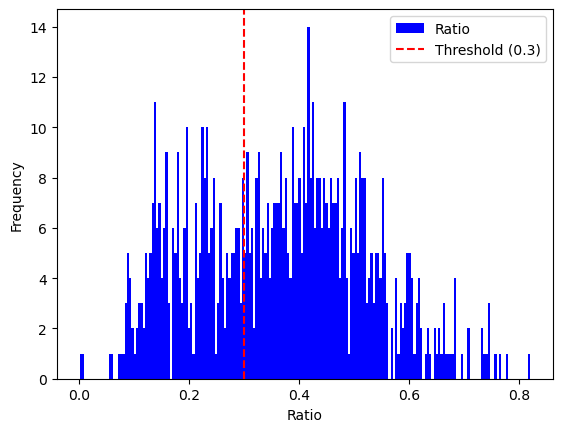

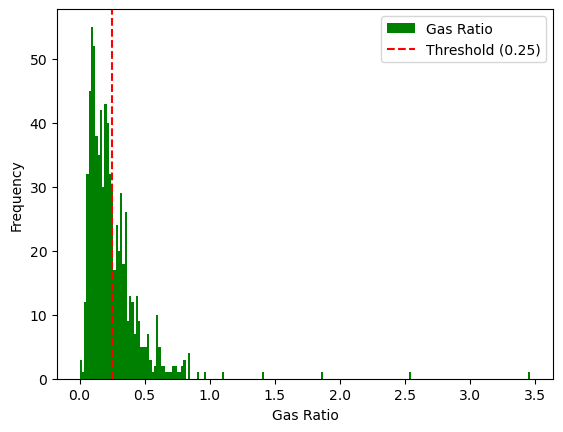

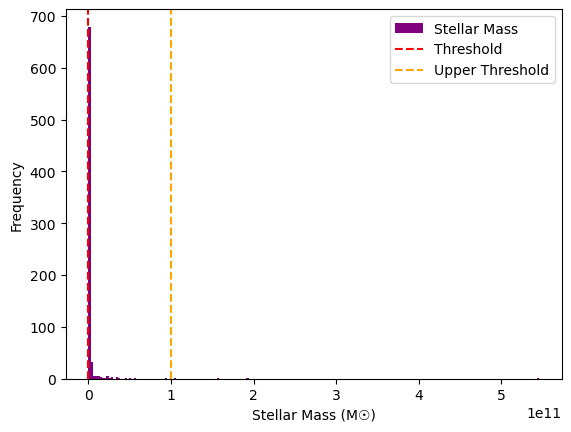

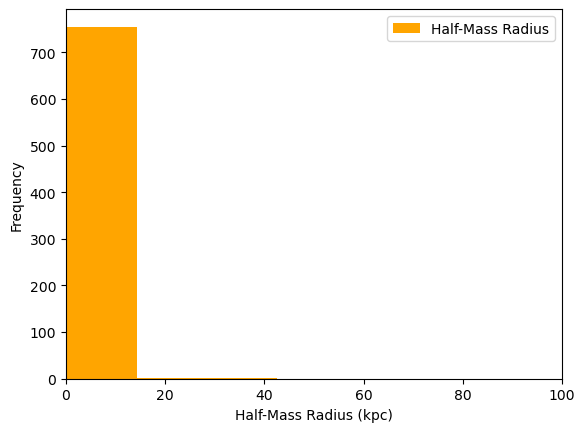

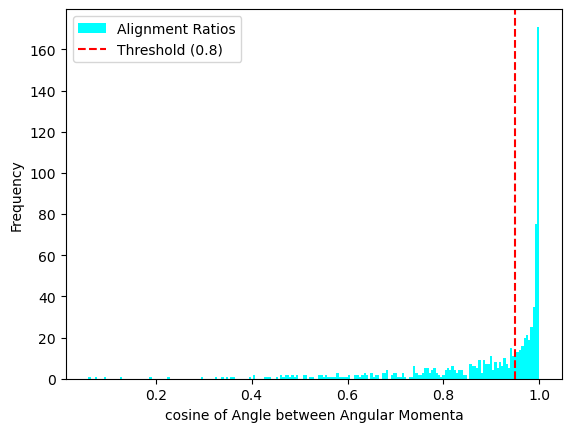

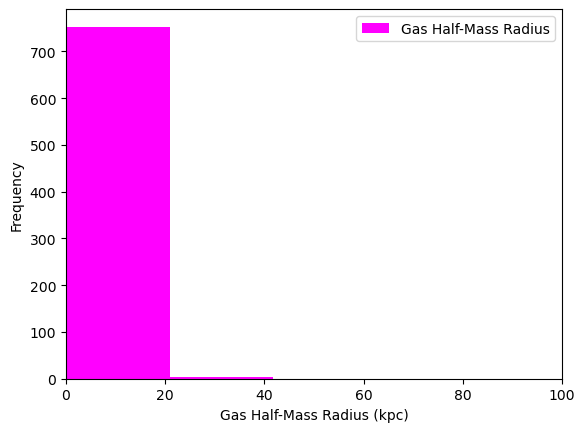

In [ ]:
plt.hist(ratio, bins=200, color='blue', label='Ratio')
plt.axvline(0.3, color='red', linestyle='--', label='Threshold (0.3)')
plt.xlabel('Ratio')
plt.ylabel('Frequency')
plt.legend()
plt.show()

plt.hist(gas_ratio, bins=200, color='green', label='Gas Ratio')
plt.axvline(0.25, color='red', linestyle='--', label='Threshold (0.25)')
plt.xlabel('Gas Ratio')
plt.ylabel('Frequency')
plt.legend()
plt.show()

plt.hist(galaxy_stellar_mass, bins=200, color='purple', label='Stellar Mass')
plt.axvline(10**(7), color='red', linestyle='--', label='Threshold')
plt.axvline(10**(11), color='orange', linestyle='--', label='Upper Threshold')
plt.xlabel('Stellar Mass (M☉)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

plt.hist(r_half, bins=1000, color='orange', label='Half-Mass Radius')
plt.xlim(0,100)
plt.xlabel('Half-Mass Radius (kpc)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

plt.hist(alignment_ratios, bins=200, color='cyan', label='Alignment Ratios')
plt.axvline(0.95, color='red', linestyle='--', label='Threshold (0.8)')
plt.xlabel('cosine of Angle between Angular Momenta')
plt.ylabel('Frequency')
plt.legend()
plt.show()

plt.hist(gas_r_half, bins=1000, color='magenta', label='Gas Half-Mass Radius')
plt.xlim(0,100)
plt.xlabel('Gas Half-Mass Radius (kpc)')
plt.ylabel('Frequency')
plt.legend()
plt.show()


In [ ]:
ratio_mask = ratio < 0.3

gas_ratio_mask = gas_ratio < 0.25

galaxy_stellar_mass_mask = (galaxy_stellar_mass > 10**(7)) & (galaxy_stellar_mass < 10**(11))

r_half_mask = (r_half < 200) & (r_half > 1)

alignment_mask = np.array(alignment_ratios) > 0.95


#total_mask = ratio_mask & gas_ratio_mask & galaxy_stellar_mass_mask & r_half_mask

total_mask = ratio_mask & galaxy_stellar_mass_mask & gas_ratio_mask & alignment_mask & r_half_mask


gal_number = gal_number[total_mask]
ratio = ratio[total_mask]
chosen_gals_com = gas_com[total_mask]

for i in range(len(chosen_gals_com)):
    cleaned = chosen_gals_com[i].replace("np.float64", "") 


    lst = ast.literal_eval(cleaned)   
    chosen_gals_com[i] = np.array(lst, dtype=float) 


print(sum(ratio_mask), sum(gas_ratio_mask), sum(galaxy_stellar_mass_mask), sum(r_half_mask), sum(alignment_mask), sum(total_mask))



270 475 755 217 415 163


In [ ]:
print(len(gal_number), "galaxies meet the criteria.")

163 galaxies meet the criteria.


In [ ]:
print(np.array(gal_number))

#np.savetxt('Chosen_galaxies_TNG.txt', np.array(gal_number), delimiter=',')

[220597 220598 220599 220600 220602 220603 220612 289387 289391 289395
 404820 432107 432108 432109 441710 444135 444137 444138 466549 503437
 509091 509092 509093 523548 536655 537488 537489 538370 538371 544001
 547844 554523 555013 575190 575863 575864 577372 580035 583027 583451
 592662 592840 596400 596401 598540 600363 602130 602653 606820 614326
 619223 620172 621409 625545 625546 625548 626052 633437 633726 634283
 634801 636729 637802 637803 641754 641755 643385 643728 646638 648363
 648364 650703 657568 658721 660010 661855 663647 666988 667858 669179
 671812 672955 673164 674596 677069 677229 679891 681696 681941 683172
 684910 685995 686753 688586 690867 694488 696147 696854 698152 698567
 699531 700338 700525 701581 703083 703702 704247 704690 705065 705119
 705241 705323 706537 708474 708747 708863 709699 713481 715782 716514
 717043 719640 719952 720822 720886 721576 722269 722584 723487 731384
 734041 734525 734874 736529 739619 740778 740953 742035 743330 746180
 74692

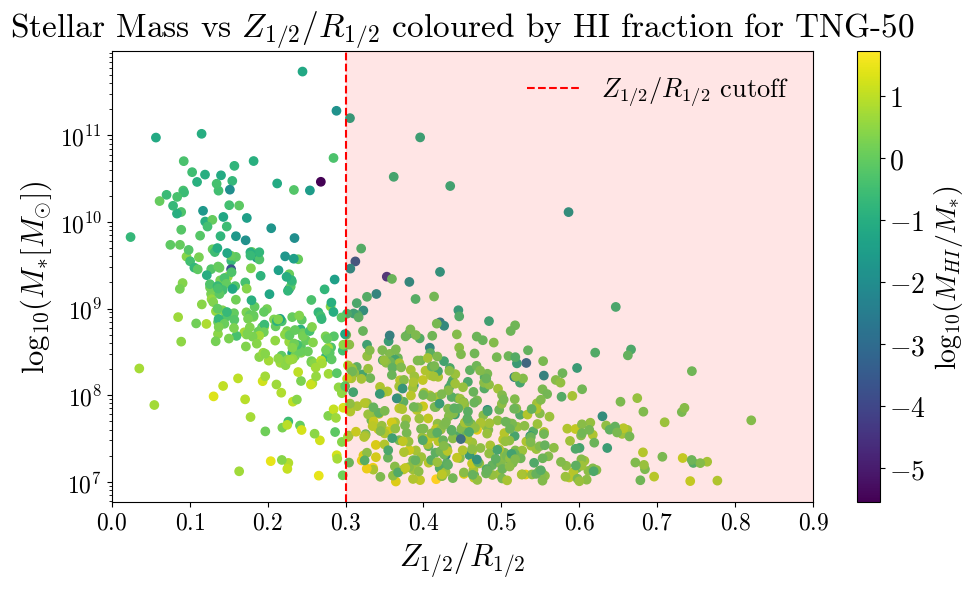

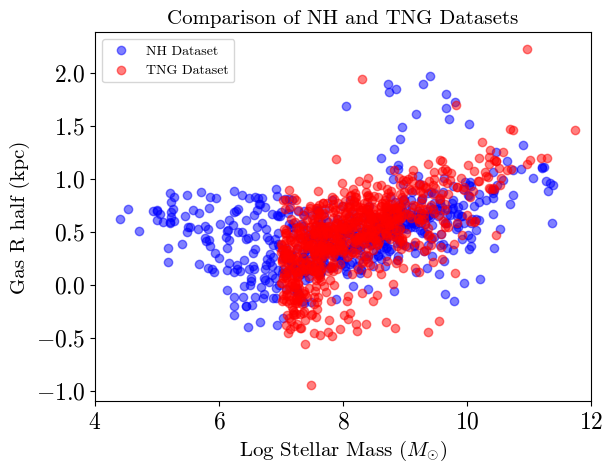

In [ ]:
NH_dataframe = pd.read_csv('/mnt/users/darnej/MPhys/galaxies_dataframe.csv')
NH_r_half_gas = np.array(NH_dataframe['gas_r_half'])
NH_stellar_mass = np.array(NH_dataframe['mass'])
NH_ratio = np.array(NH_dataframe['ratio'])

TNG_dataframe = pd.read_csv('Galaxy_dataframe_TNG.csv')
TNG_r_half_gas = np.array(TNG_dataframe['gas_r_half'])
TNG_stellar_mass = np.array(TNG_dataframe['stellar_mass'])
TNG_ratio = np.array(TNG_dataframe['ratio'])
TNG_t_total_mass = np.array(TNG_dataframe['T_total_mass'])
TNG_gas_mass = np.array(TNG_dataframe['gas_total_mass'])

mask = (NH_stellar_mass > 0) & (NH_r_half_gas > 0) & (NH_ratio > 0.01)
NH_stellar_mass = NH_stellar_mass[mask]
NH_r_half_gas = NH_r_half_gas[mask]
NH_ratio = NH_ratio[mask]

mask = (TNG_stellar_mass > 0) & (TNG_r_half_gas > 0) & (TNG_ratio > 0.01)
TNG_stellar_mass = TNG_stellar_mass[mask]
TNG_r_half_gas = TNG_r_half_gas[mask]
TNG_ratio = TNG_ratio[mask]
TNG_t_total_mass = TNG_t_total_mass[mask]
TNG_gas_mass = TNG_gas_mass[mask]

plt.rcParams["axes.formatter.use_mathtext"] = True
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams['font.family'] = 'cmr10'  # Computer Modern Roman
plt.rcParams["xtick.labelsize"] = 17   # Increase x-axis tick font size
plt.rcParams["ytick.labelsize"] = 17   # Increase y-axis tick font size

HI_fraction = TNG_gas_mass /TNG_stellar_mass

plt.figure(figsize=(10, 6))
sc = plt.scatter(TNG_ratio, TNG_stellar_mass, c=np.log10(HI_fraction), cmap='viridis')
#plt.xscale('log')
plt.yscale('log')

cbar = plt.colorbar(sc, label='$M_{HI}/M_{*}$')
cbar.set_label("$\log_{10}(M_{HI}/M_{*})$", fontsize=20)
cbar.ax.tick_params(labelsize=20)

plt.axvline(0.3, color='red', linestyle='--', label='$Z_{1/2}/R_{1/2}$ cutoff')

plt.axvspan(0.3, 1, color='red', alpha=0.1)

plt.xlim(0, 0.9)

plt.ylabel('$\log_{10}{(M_{*}[M_{\odot}])}$', size=22)
plt.xlabel('$Z_{1/2}/R_{1/2}$', size=22)
plt.title('Stellar Mass vs $Z_{1/2}/R_{1/2}$ coloured by HI fraction for TNG-50', size=24)

plt.legend(prop = {'size': 19}, frameon = False)

plt.tight_layout()
plt.show()


plt.scatter(np.log10(NH_stellar_mass), np.log10(NH_r_half_gas), color='blue', label='NH Dataset', alpha=0.5)
plt.scatter(np.log10(TNG_stellar_mass), np.log10(TNG_r_half_gas), color='red', label='TNG Dataset', alpha=0.5)
plt.xlabel('Log Stellar Mass ($M_{\odot}$)', size=15)
plt.ylabel('Gas R half (kpc)', size=15)
plt.title('Comparison of NH and TNG Datasets', size=15)
plt.xlim(4, 12)

plt.legend()
plt.show()



In [ ]:
gal_com = []
for i in range(len(gal_number)):
    gal_com.append(list(chosen_gals_com)[i])

all_close_gals = defaultdict(list)

for i in range(len(gal_com)):
    holder = gal_com
    holder = holder - gal_com[i]
    holder = np.linalg.norm(holder, axis=1)

    #DEFINE MINIMUM DISTANCE FOR CLOSE GALAXIES
    mask = (holder < 100) & (holder > 0)

    if np.sum(mask) > 0:
        close_gals = gal_number[mask]
        #print("Galaxy", chosen_gals[i], "has a close neighbour within 300 kpc.")
        #print("Close galaxies:", close_gals)
        for gal in close_gals:
            all_close_gals[gal].append(gal)



close_gals = list(all_close_gals.keys())


print(len(close_gals))


chosen_gals_final = []
for gal in gal_number:
    if gal not in close_gals:
        chosen_gals_final.append(gal)

print("Final chosen galaxies:", chosen_gals_final)
print("Number of chosen galaxies:", len(chosen_gals_final))
np.savetxt('/mnt/users/darnej/MPhys/TNG-50/Chosen_galaxies_TNG.txt', np.array(chosen_gals_final), delimiter=',')



10
Final chosen galaxies: [220597, 220598, 220599, 220600, 220602, 220603, 220612, 289387, 289391, 289395, 404820, 432107, 432108, 432109, 441710, 444135, 444137, 444138, 466549, 503437, 509092, 523548, 536655, 537488, 537489, 544001, 547844, 554523, 555013, 575190, 575863, 575864, 577372, 580035, 583027, 583451, 592662, 592840, 596400, 596401, 598540, 600363, 602130, 602653, 606820, 614326, 619223, 620172, 621409, 625548, 626052, 633437, 633726, 634283, 634801, 636729, 643385, 643728, 646638, 648363, 648364, 650703, 657568, 658721, 660010, 661855, 663647, 666988, 667858, 669179, 671812, 672955, 673164, 674596, 677069, 677229, 679891, 681696, 681941, 683172, 684910, 685995, 686753, 688586, 690867, 694488, 696147, 696854, 698152, 698567, 699531, 700338, 700525, 701581, 703083, 703702, 704247, 704690, 705065, 705119, 705241, 705323, 706537, 708474, 708747, 708863, 709699, 713481, 715782, 716514, 717043, 719640, 719952, 720822, 720886, 721576, 722269, 722584, 723487, 731384, 734041, 73452